# Exploratory Data Analysis — Health & Personal Care (Amazon Reviews)

This notebook performs a comprehensive EDA on two datasets:
1. **Reviews** (`Health_and_Personal_Care.jsonl`) — individual user reviews
2. **Metadata** (`meta_Health_and_Personal_Care.jsonl`) — product-level information

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})

# ── Load datasets ──────────────────────────────────────────────
reviews = pd.read_json("../io/extracted/Health_and_Personal_Care.jsonl", lines=True)
meta    = pd.read_json("../io/extracted/meta_Health_and_Personal_Care.jsonl", lines=True)

print(f"Reviews shape : {reviews.shape}")
print(f"Metadata shape: {meta.shape}")

Reviews shape : (494121, 10)
Metadata shape: (60293, 14)


## 1 — Dataset Overview

In [2]:
# ── Quick look at the reviews dataset ──────────────────────────
print("─── Reviews ───")
print(reviews.dtypes, "\n")
print(reviews.isnull().sum(), "\n")
reviews.head(3)

─── Reviews ───
rating                        int64
title                        object
text                         object
images                       object
asin                         object
parent_asin                  object
user_id                      object
timestamp            datetime64[ns]
helpful_vote                  int64
verified_purchase              bool
dtype: object 

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64 



,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,4,12 mg is 12 on the periodic table people! Mg f...,This review is more to clarify someone else’s ...,[],B07TDSJZMR,B07TDSJZMR,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-06 00:49:35.902,3,True
1,5,Save the lanet using less plastic.,Love these easy multitasking bleach tablets. B...,[],B08637FWWF,B08637FWWF,AEVWAM3YWN5URJVJIZZ6XPD2MKIA,2020-11-02 22:03:06.880,3,True
2,5,Fantastic,I have been suffering a couple months with hee...,[],B07KJVGNN5,B07KJVGNN5,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2019-07-24 11:13:58.905,0,True


In [3]:
# ── Quick look at the metadata dataset ─────────────────────────
print("─── Metadata ───")
print(meta.dtypes, "\n")
print(meta.isnull().sum(), "\n")
meta.head(3)

─── Metadata ───
main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
description         object
price              float64
images              object
videos              object
store               object
categories          object
details             object
parent_asin         object
bought_together    float64
dtype: object 

main_category          0
title                  0
average_rating         0
rating_number          0
features               0
description            0
price              49757
images                 0
videos                 0
store               2346
categories             0
details                0
parent_asin            0
bought_together    60293
dtype: int64 



,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Health & Personal Care,Silicone Bath Body Brush Exfoliator Shower Bac...,3.9,7,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Rzoeox,[],{'Package Dimensions': '15 x 3.3 x 1.5 inches;...,B07V346GZH,NaN
1,Health & Personal Care,"iPhone 7 Plus 8 Plus Screen Protector, ZHXIN T...",3.8,2,[Tough and Robust: Like all 78X screen protect...,[Features: 2.5D Arc Edge Treatment: The edge i...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],ZHXIN,[],"{'Brand': 'ZHXIN', 'Compatible Devices': 'Cell...",B075W927RH,NaN
2,Health & Personal Care,Zig Zag Rolling Machine 70mm Size With FREE BO...,3.9,7,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],None,[],{'Package Dimensions': '4.1 x 1.8 x 0.3 inches...,B01FB26VKY,NaN


In [4]:
# ── Basic statistics for numerical columns ─────────────────────
print("─── Reviews numerical summary ───")
display(reviews.describe())
print("\n─── Metadata numerical summary ───")
display(meta[["average_rating", "rating_number"]].describe())

─── Reviews numerical summary ───


,rating,timestamp,helpful_vote
count,494121.000000,494121,494121.000000
mean,3.996523,2018-11-17 19:50:46.048134656,1.131802
min,1.000000,2001-02-05 03:50:11,0.000000
25%,3.000000,2016-12-24 22:14:13,0.000000
50%,5.000000,2019-04-01 06:57:03.632999936,0.000000
75%,5.000000,2021-01-04 20:01:21.267000064,1.000000
max,5.000000,2023-09-11 05:03:12.467000,7326.000000
std,1.478626,NaN,15.437500



─── Metadata numerical summary ───


,average_rating,rating_number
count,60293.000000,60293.000000
mean,3.979625,61.924718
std,0.846449,479.554144
min,1.000000,1.000000
25%,3.500000,3.000000
50%,4.100000,10.000000
75%,4.600000,32.000000
max,5.000000,60033.000000


## 2 — Rating Distribution

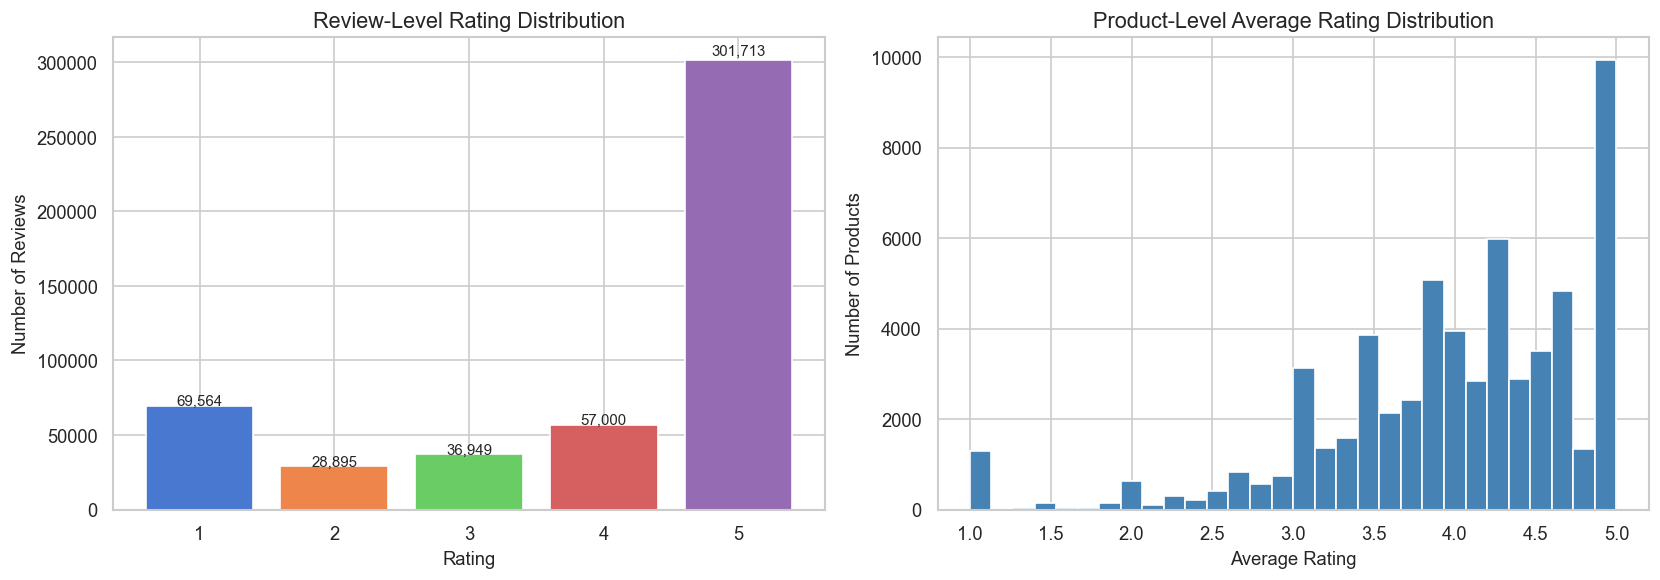

Mean review rating: 4.00
Median review rating: 5.0
Mean product avg rating: 3.98


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Review-level rating distribution
rating_counts = reviews["rating"].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(str), rating_counts.values, color=sns.color_palette("muted"))
axes[0].set_title("Review-Level Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of Reviews")
for i, v in enumerate(rating_counts.values):
    axes[0].text(i, v + v * 0.01, f"{v:,}", ha="center", fontsize=9)

# Product-level average rating distribution
axes[1].hist(meta["average_rating"].dropna(), bins=30, edgecolor="white", color="steelblue")
axes[1].set_title("Product-Level Average Rating Distribution")
axes[1].set_xlabel("Average Rating")
axes[1].set_ylabel("Number of Products")

plt.tight_layout()
plt.show()

print(f"Mean review rating: {reviews['rating'].mean():.2f}")
print(f"Median review rating: {reviews['rating'].median():.1f}")
print(f"Mean product avg rating: {meta['average_rating'].mean():.2f}")

## 3 — Review Text Length Analysis

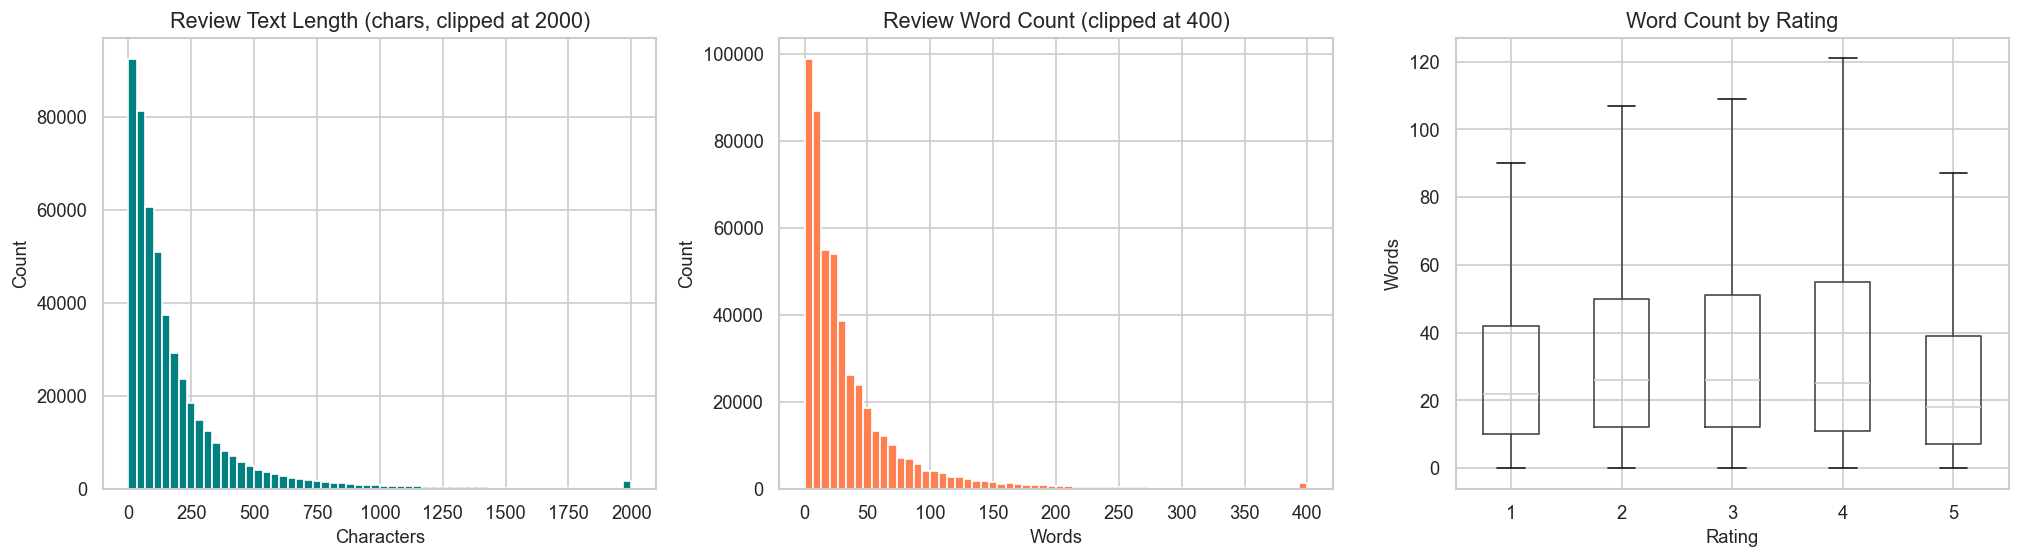

       text_len  word_count  title_len
count  494121.0    494121.0   494121.0
mean      188.2        35.2       22.4
std       284.9        52.2       17.4
min         0.0         0.0        1.0
25%        45.0         8.0       10.0
50%       107.0        20.0       16.0
75%       225.0        43.0       29.0
max     19956.0      3455.0      287.0


In [6]:
# ── Feature engineering: text length & word count ──────────────
reviews["text_len"]   = reviews["text"].fillna("").str.len()
reviews["word_count"] = reviews["text"].fillna("").str.split().str.len()
reviews["title_len"]  = reviews["title"].fillna("").str.len()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Text length distribution (chars)
axes[0].hist(reviews["text_len"].clip(upper=2000), bins=60, edgecolor="white", color="teal")
axes[0].set_title("Review Text Length (chars, clipped at 2000)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

# Word count distribution
axes[1].hist(reviews["word_count"].clip(upper=400), bins=60, edgecolor="white", color="coral")
axes[1].set_title("Review Word Count (clipped at 400)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Count")

# Text length by rating
reviews.boxplot(column="word_count", by="rating", ax=axes[2], showfliers=False)
axes[2].set_title("Word Count by Rating")
axes[2].set_xlabel("Rating")
axes[2].set_ylabel("Words")
plt.suptitle("")  # remove auto title from pandas boxplot

plt.tight_layout()
plt.show()

print(reviews[["text_len", "word_count", "title_len"]].describe().round(1))

## 4 — Verified vs Non-Verified Purchases

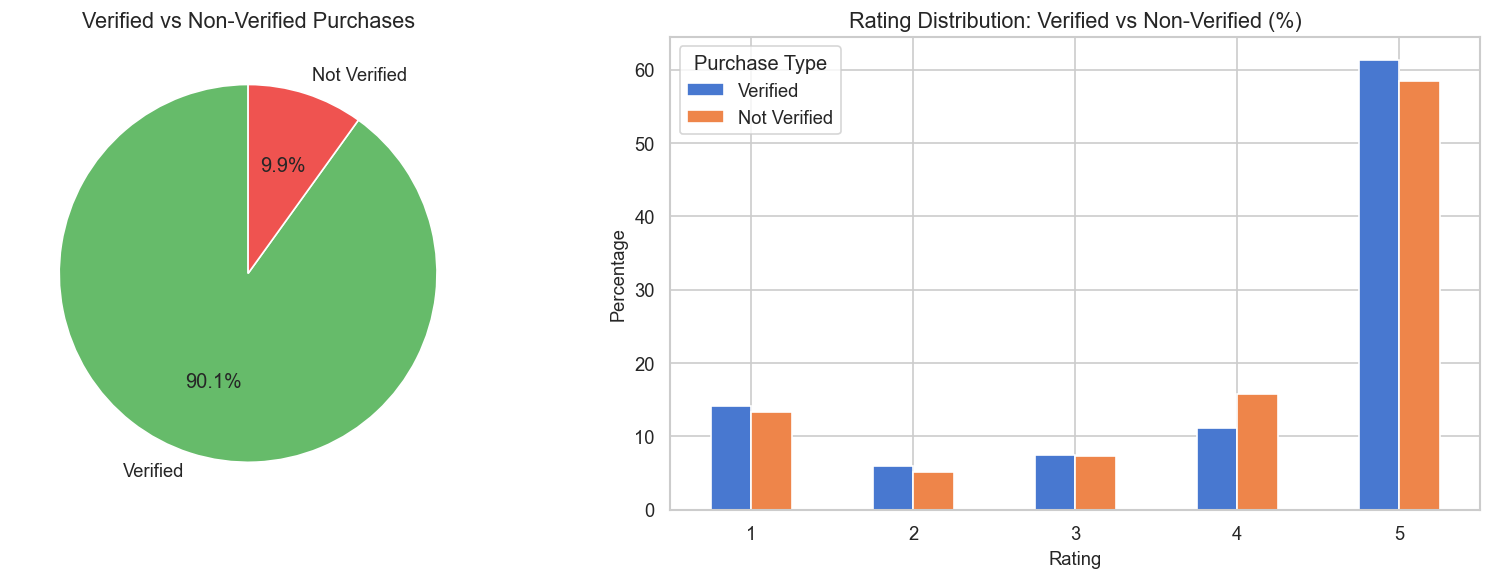

Verified mean rating:     4.00
Non-verified mean rating: 4.01


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Proportion
vp_counts = reviews["verified_purchase"].value_counts()
axes[0].pie(vp_counts.values, labels=["Verified", "Not Verified"],
            autopct="%1.1f%%", startangle=90, colors=["#66bb6a", "#ef5350"])
axes[0].set_title("Verified vs Non-Verified Purchases")

# Rating comparison
verified_ratings   = reviews[reviews["verified_purchase"] == True]["rating"]
unverified_ratings = reviews[reviews["verified_purchase"] == False]["rating"]

rating_comp = pd.DataFrame({
    "Verified":     verified_ratings.value_counts().sort_index(),
    "Not Verified": unverified_ratings.value_counts().sort_index(),
}).fillna(0)
# Normalise to percentages for fair comparison
rating_comp_pct = rating_comp.div(rating_comp.sum()) * 100
rating_comp_pct.plot.bar(ax=axes[1], edgecolor="white")
axes[1].set_title("Rating Distribution: Verified vs Non-Verified (%)")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Percentage")
axes[1].legend(title="Purchase Type")
axes[1].set_xticklabels(rating_comp_pct.index.astype(int).astype(str), rotation=0)

plt.tight_layout()
plt.show()

print(f"Verified mean rating:     {verified_ratings.mean():.2f}")
print(f"Non-verified mean rating: {unverified_ratings.mean():.2f}")

## 5 — Temporal Analysis (Reviews Over Time)

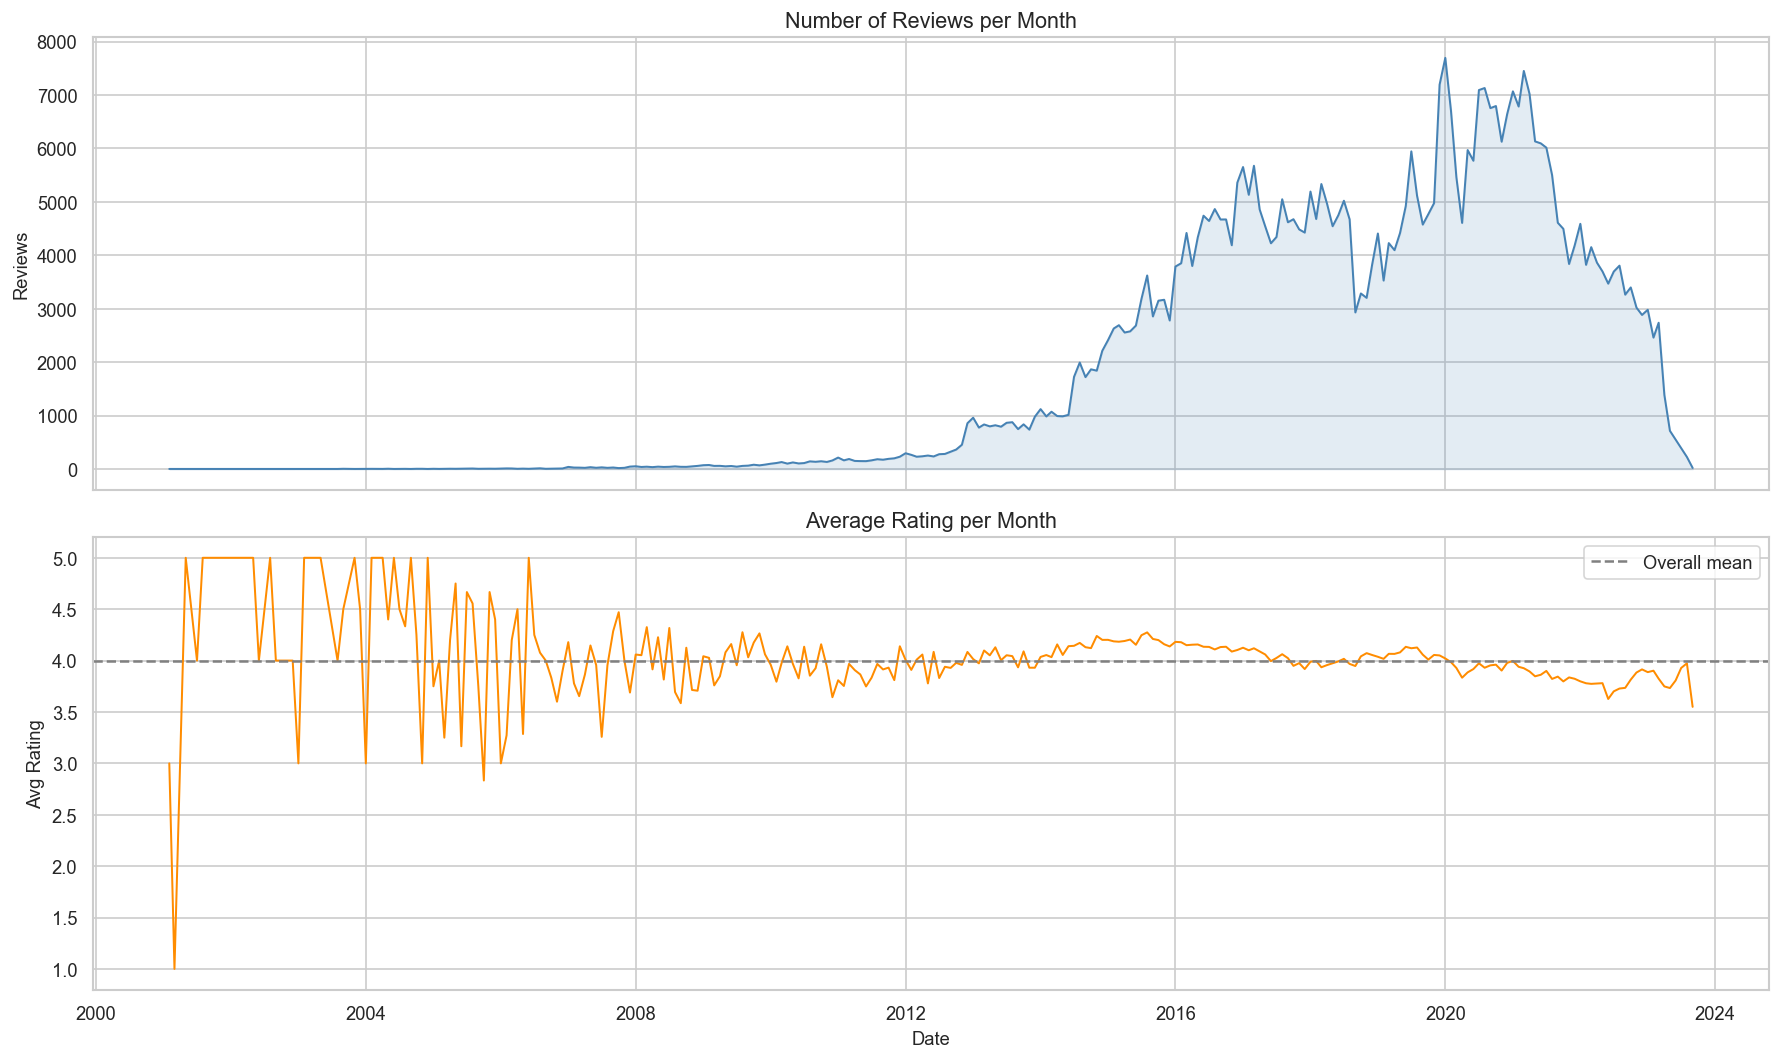

Date range: 2001-02-05 → 2023-09-11


In [8]:
# ── Convert timestamp to datetime ──────────────────────────────
reviews["date"] = pd.to_datetime(reviews["timestamp"], unit="ms")
reviews["year_month"] = reviews["date"].dt.to_period("M")

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

# Reviews per month
monthly = reviews.groupby("year_month").size()
monthly.index = monthly.index.to_timestamp()
axes[0].plot(monthly.index, monthly.values, linewidth=1.2, color="steelblue")
axes[0].fill_between(monthly.index, monthly.values, alpha=0.15, color="steelblue")
axes[0].set_title("Number of Reviews per Month")
axes[0].set_ylabel("Reviews")

# Average rating per month
monthly_rating = reviews.groupby("year_month")["rating"].mean()
monthly_rating.index = monthly_rating.index.to_timestamp()
axes[1].plot(monthly_rating.index, monthly_rating.values, linewidth=1.2, color="darkorange")
axes[1].axhline(reviews["rating"].mean(), ls="--", color="gray", label="Overall mean")
axes[1].set_title("Average Rating per Month")
axes[1].set_ylabel("Avg Rating")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Date range: {reviews['date'].min().date()} → {reviews['date'].max().date()}")

## 6 — Helpful Votes Analysis

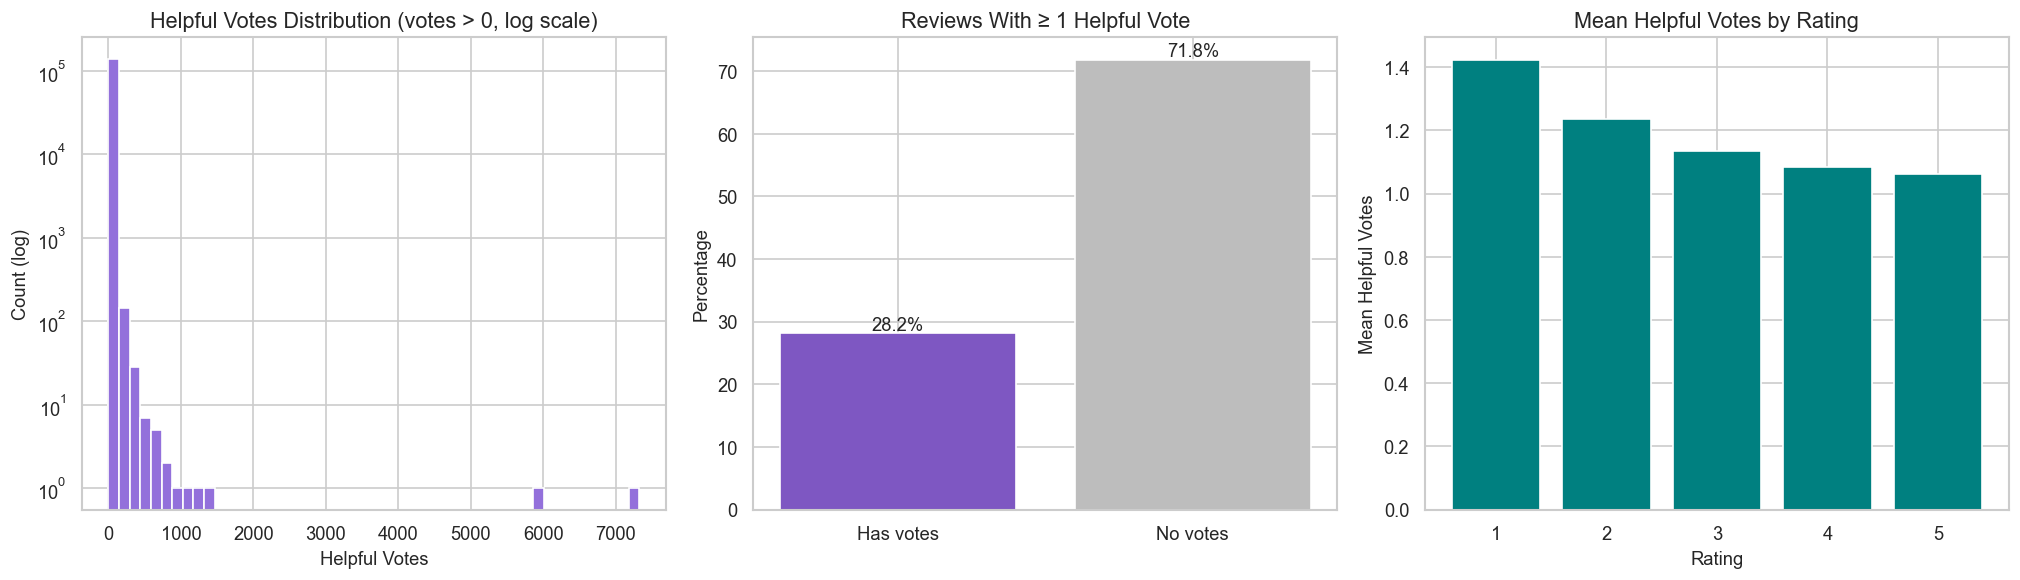

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Helpful vote distribution (log scale for visibility)
hv = reviews["helpful_vote"]
axes[0].hist(hv[hv > 0], bins=50, edgecolor="white", color="mediumpurple", log=True)
axes[0].set_title("Helpful Votes Distribution (votes > 0, log scale)")
axes[0].set_xlabel("Helpful Votes")
axes[0].set_ylabel("Count (log)")

# % of reviews with at least one helpful vote
has_vote = (hv > 0).mean() * 100
axes[1].bar(["Has votes", "No votes"], [has_vote, 100 - has_vote],
            color=["#7e57c2", "#bdbdbd"], edgecolor="white")
axes[1].set_title("Reviews With ≥ 1 Helpful Vote")
axes[1].set_ylabel("Percentage")
for i, v in enumerate([has_vote, 100 - has_vote]):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11)

# Mean helpful votes per rating
mean_hv_by_rating = reviews.groupby("rating")["helpful_vote"].mean()
axes[2].bar(mean_hv_by_rating.index.astype(int).astype(str), mean_hv_by_rating.values, color="teal")
axes[2].set_title("Mean Helpful Votes by Rating")
axes[2].set_xlabel("Rating")
axes[2].set_ylabel("Mean Helpful Votes")

plt.tight_layout()
plt.show()

## 7 — Product Metadata: Prices & Popularity

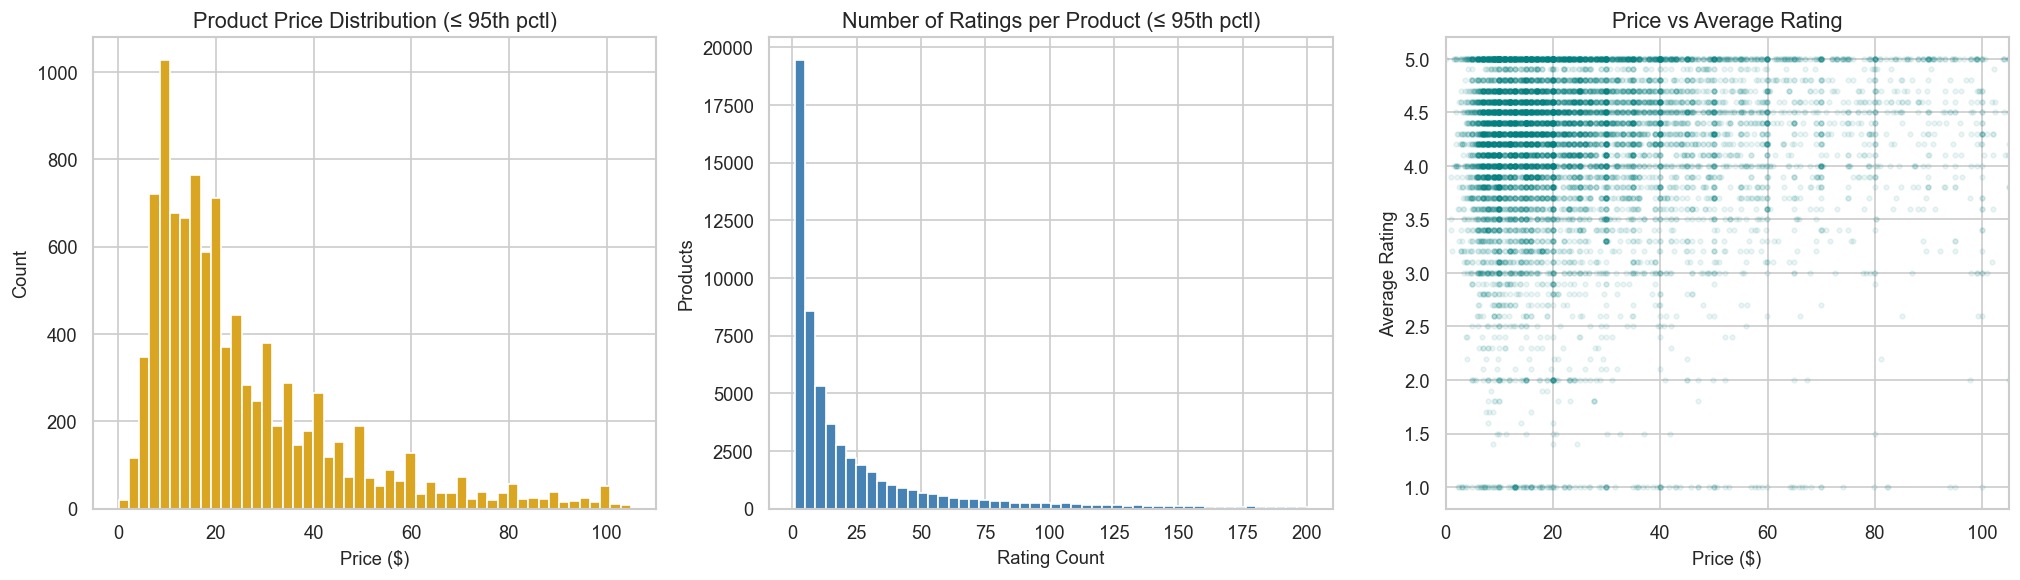

Products with price info: 10,536 / 60,293 (17.5%)
Median price: $19.99
Median ratings per product: 10


In [10]:
# ── Parse price (stored as string like "$12.99" or range) ──────
meta["price_clean"] = (
    meta["price"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)   # keep digits and dots
    .replace("", np.nan)
    .astype(float)
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Price distribution
prices = meta["price_clean"].dropna()
prices_clipped = prices[prices <= prices.quantile(0.95)]   # clip at 95th percentile
axes[0].hist(prices_clipped, bins=50, edgecolor="white", color="goldenrod")
axes[0].set_title("Product Price Distribution (≤ 95th pctl)")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")

# Rating count per product (popularity)
rc = meta["rating_number"]
axes[1].hist(rc[rc <= rc.quantile(0.95)], bins=50, edgecolor="white", color="steelblue")
axes[1].set_title("Number of Ratings per Product (≤ 95th pctl)")
axes[1].set_xlabel("Rating Count")
axes[1].set_ylabel("Products")

# Price vs Average Rating
axes[2].scatter(meta["price_clean"], meta["average_rating"], alpha=0.08, s=8, color="teal")
axes[2].set_title("Price vs Average Rating")
axes[2].set_xlabel("Price ($)")
axes[2].set_ylabel("Average Rating")
axes[2].set_xlim(0, prices.quantile(0.95))

plt.tight_layout()
plt.show()

print(f"Products with price info: {prices.shape[0]:,} / {meta.shape[0]:,} ({prices.shape[0]/meta.shape[0]*100:.1f}%)")
print(f"Median price: ${prices.median():.2f}")
print(f"Median ratings per product: {rc.median():.0f}")

## 8 — Top Stores and Products

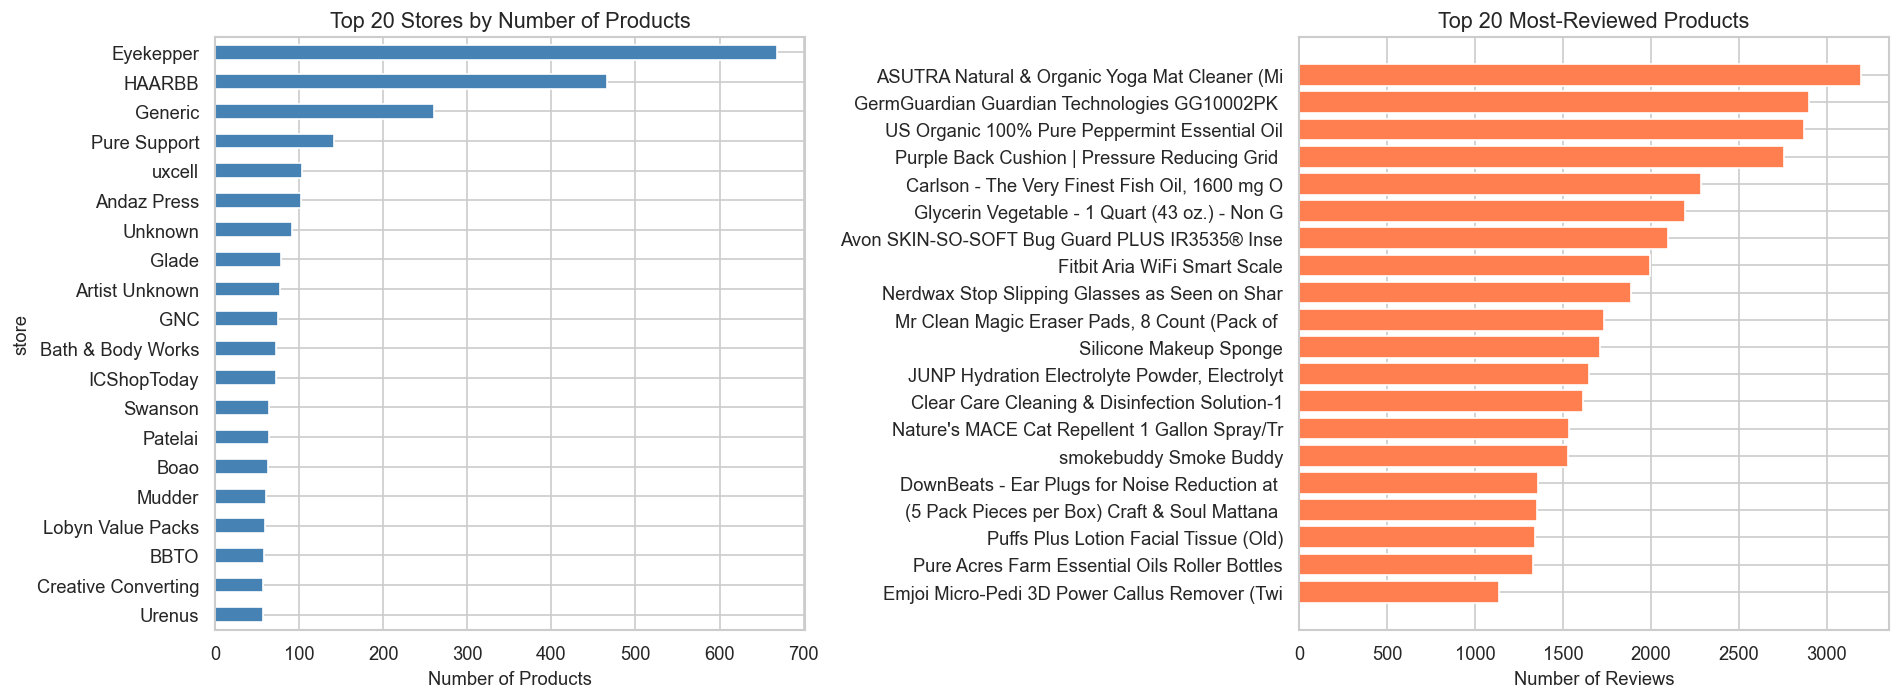

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 stores by number of products
top_stores = meta["store"].value_counts().head(20)
top_stores.plot.barh(ax=axes[0], color="steelblue", edgecolor="white")
axes[0].invert_yaxis()
axes[0].set_title("Top 20 Stores by Number of Products")
axes[0].set_xlabel("Number of Products")

# Top 20 most-reviewed products
reviews_per_product = reviews.groupby("parent_asin").size().sort_values(ascending=False).head(20)
# Map ASINs to product titles
asin_to_title = meta.set_index("parent_asin")["title"].to_dict()
product_labels = [asin_to_title.get(a, a)[:45] for a in reviews_per_product.index]
axes[1].barh(product_labels, reviews_per_product.values, color="coral", edgecolor="white")
axes[1].invert_yaxis()
axes[1].set_title("Top 20 Most-Reviewed Products")
axes[1].set_xlabel("Number of Reviews")

plt.tight_layout()
plt.show()

## 9 — Review Images Analysis

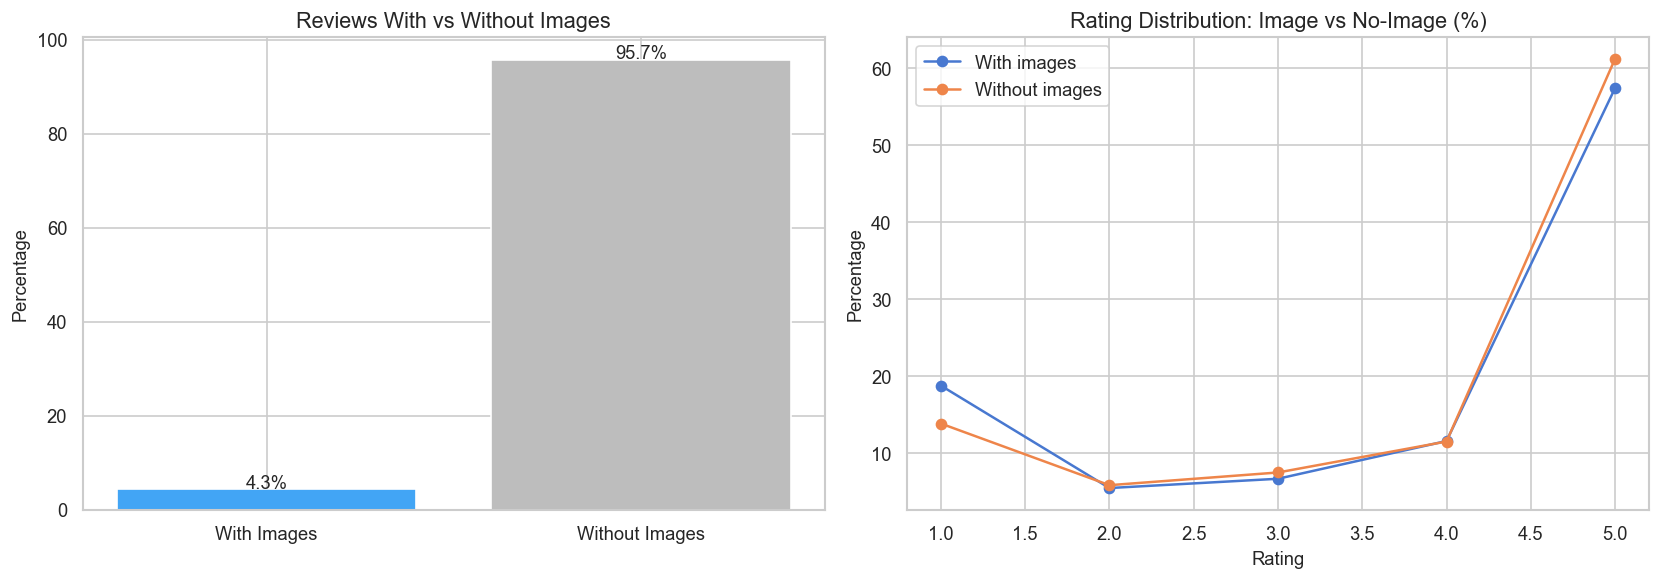

Mean rating WITH images:    3.83
Mean rating WITHOUT images: 4.00


In [12]:
# ── Do reviews with images differ from those without? ──────────
reviews["has_images"] = reviews["images"].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)
reviews["n_images"]   = reviews["images"].apply(lambda x: len(x) if isinstance(x, list) else 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Proportion with images
img_pct = reviews["has_images"].mean() * 100
axes[0].bar(["With Images", "Without Images"], [img_pct, 100 - img_pct],
            color=["#42a5f5", "#bdbdbd"], edgecolor="white")
axes[0].set_title("Reviews With vs Without Images")
axes[0].set_ylabel("Percentage")
for i, v in enumerate([img_pct, 100 - img_pct]):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=11)

# Rating distribution for image vs no-image reviews
for label, subset in [("With images", reviews[reviews["has_images"]]),
                       ("Without images", reviews[~reviews["has_images"]])]:
    rc = subset["rating"].value_counts(normalize=True).sort_index() * 100
    axes[1].plot(rc.index, rc.values, marker="o", label=label)
axes[1].set_title("Rating Distribution: Image vs No-Image (%)")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Percentage")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean rating WITH images:    {reviews.loc[reviews['has_images'], 'rating'].mean():.2f}")
print(f"Mean rating WITHOUT images: {reviews.loc[~reviews['has_images'], 'rating'].mean():.2f}")

## 10 — User Activity Distribution

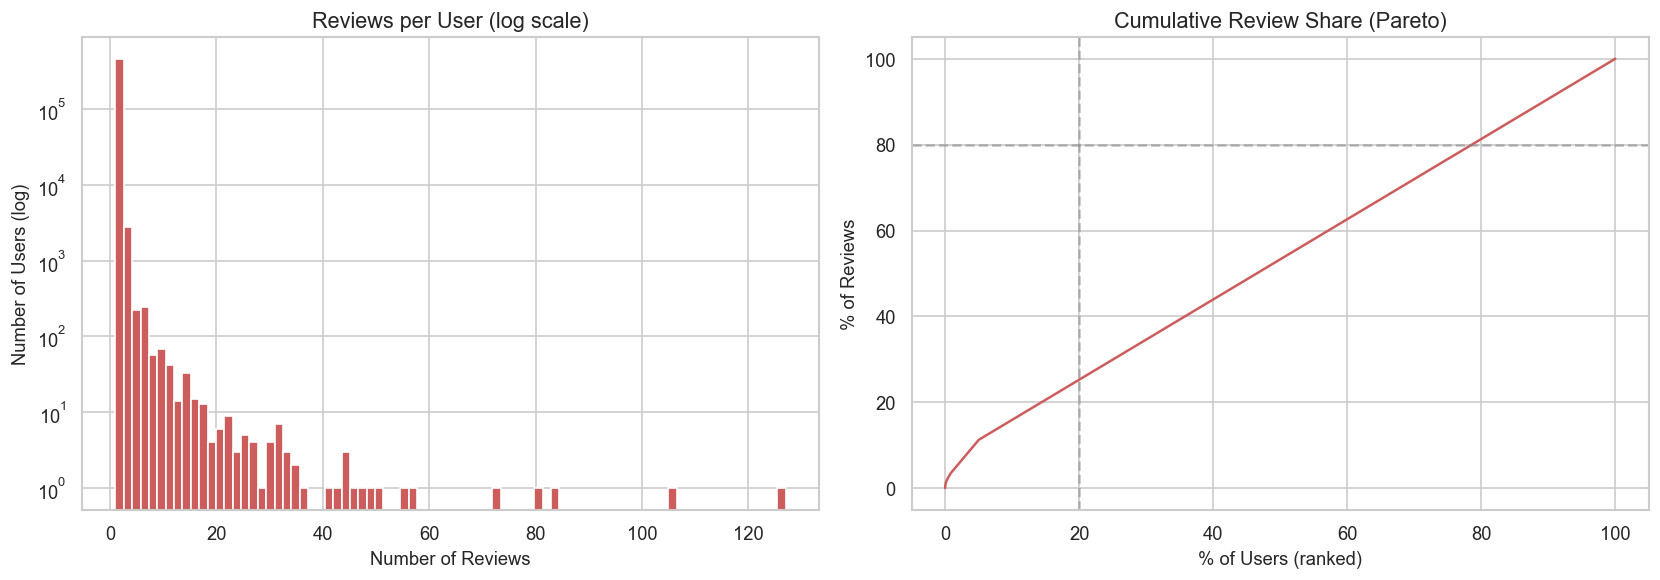

Total unique users: 461,656
Single-review users: 438,710 (95.0%)
Mean reviews/user: 1.1
Max reviews by 1 user: 127


In [13]:
# ── How many reviews does each user write? ─────────────────────
user_counts = reviews["user_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_counts.values, bins=80, edgecolor="white", color="indianred", log=True)
axes[0].set_title("Reviews per User (log scale)")
axes[0].set_xlabel("Number of Reviews")
axes[0].set_ylabel("Number of Users (log)")

# Cumulative share — what % of reviews come from top N% of users?
sorted_counts = user_counts.sort_values(ascending=False).values
cum_share = np.cumsum(sorted_counts) / sorted_counts.sum() * 100
user_pct  = np.arange(1, len(cum_share) + 1) / len(cum_share) * 100
axes[1].plot(user_pct, cum_share, linewidth=1.5, color="indianred")
axes[1].axhline(80, ls="--", color="gray", alpha=0.5)
axes[1].axvline(20, ls="--", color="gray", alpha=0.5)
axes[1].set_title("Cumulative Review Share (Pareto)")
axes[1].set_xlabel("% of Users (ranked)")
axes[1].set_ylabel("% of Reviews")

plt.tight_layout()
plt.show()

print(f"Total unique users: {user_counts.shape[0]:,}")
print(f"Single-review users: {(user_counts == 1).sum():,} ({(user_counts == 1).mean()*100:.1f}%)")
print(f"Mean reviews/user: {user_counts.mean():.1f}")
print(f"Max reviews by 1 user: {user_counts.max()}")

## 11 — Text-Level NLP Insights: Most Frequent Words in Positive vs Negative Reviews

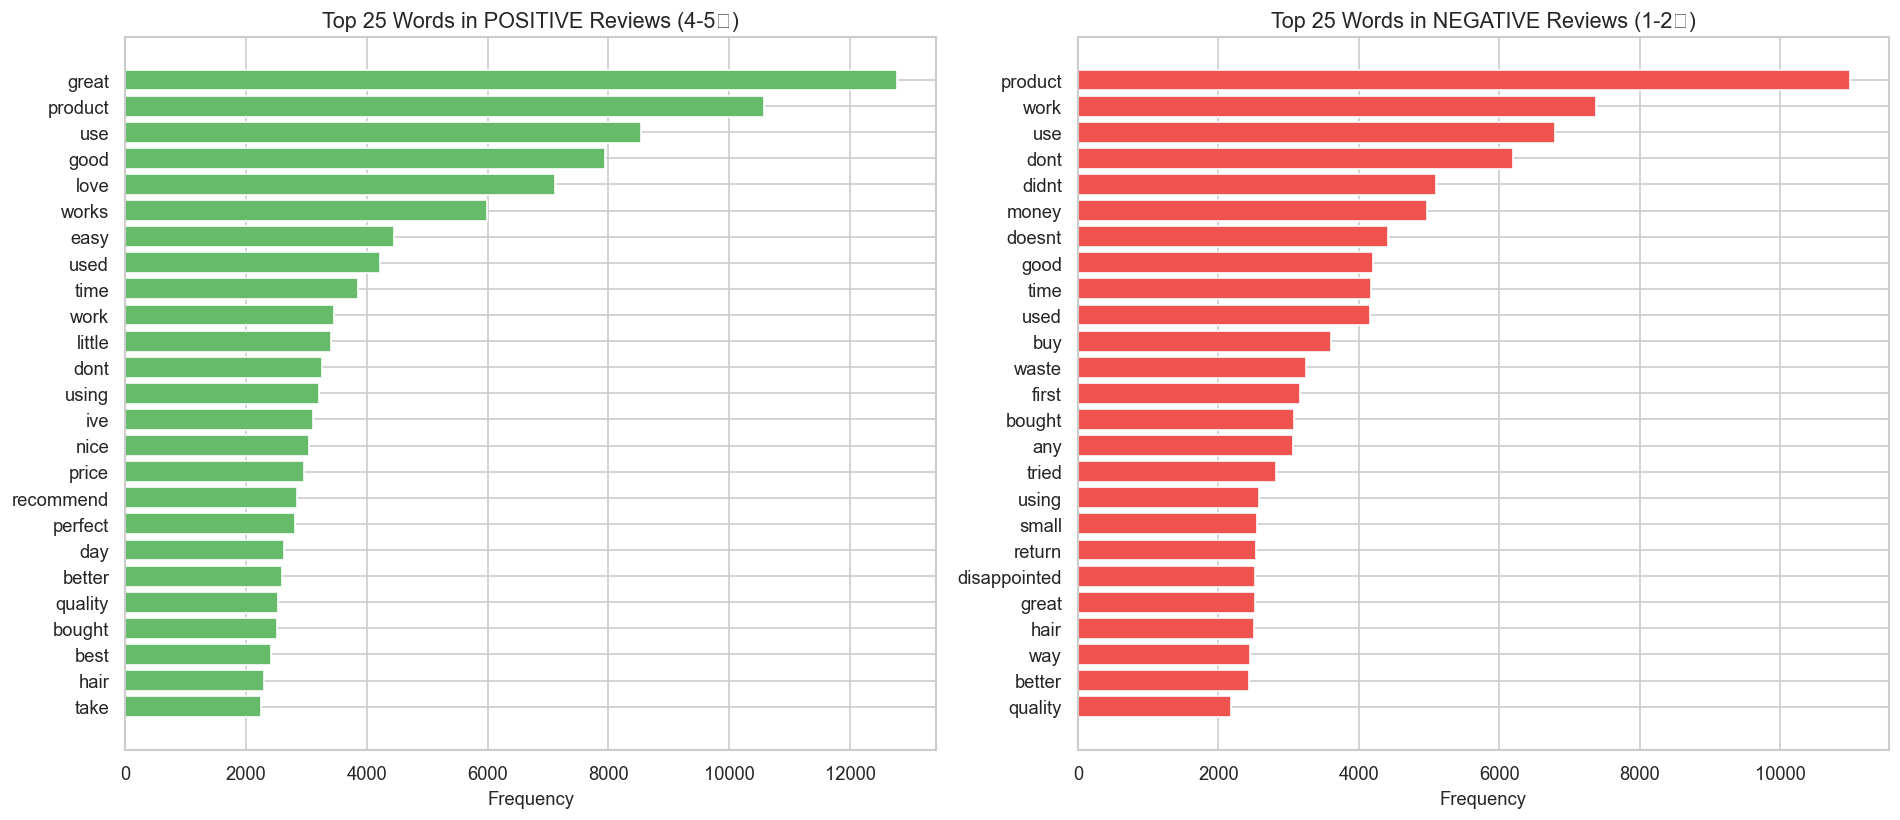

In [14]:
import re, string

# ── Simple tokeniser (no heavy NLP dependency) ────────────────
STOPWORDS = {
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your",
    "yours", "yourself", "yourselves", "he", "him", "his", "himself", "she", "her",
    "hers", "herself", "it", "its", "itself", "they", "them", "their", "theirs",
    "themselves", "what", "which", "who", "whom", "this", "that", "these", "those",
    "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had",
    "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if",
    "or", "because", "as", "until", "while", "of", "at", "by", "for", "with",
    "about", "against", "between", "through", "during", "before", "after", "above",
    "below", "to", "from", "up", "down", "in", "out", "on", "off", "over", "under",
    "again", "further", "then", "once", "here", "there", "when", "where", "why",
    "how", "all", "both", "each", "few", "more", "most", "other", "some", "such",
    "no", "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s",
    "t", "can", "will", "just", "don", "should", "now", "d", "ll", "m", "o", "re",
    "ve", "y", "ain", "aren", "couldn", "didn", "doesn", "hadn", "hasn", "haven",
    "isn", "ma", "mightn", "mustn", "needn", "shan", "shouldn", "wasn", "weren",
    "won", "wouldn", "also", "would", "could", "one", "two", "get", "got", "like",
    "really", "much", "well", "even", "still", "go", "going", "back", "make",
    "us", "thing", "things", "made",
}

def tokenise(text: str) -> list[str]:
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return [w for w in text.split() if w not in STOPWORDS and len(w) > 2]

# Positive (4-5) vs Negative (1-2)
pos_text = reviews.loc[reviews["rating"] >= 4, "text"].dropna().sample(min(50_000, (reviews["rating"]>=4).sum()), random_state=42)
neg_text = reviews.loc[reviews["rating"] <= 2, "text"].dropna().sample(min(50_000, (reviews["rating"]<=2).sum()), random_state=42)

pos_words = Counter()
neg_words = Counter()
for t in pos_text:
    pos_words.update(tokenise(t))
for t in neg_text:
    neg_words.update(tokenise(t))

TOP_N = 25
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Positive
pw = pos_words.most_common(TOP_N)
axes[0].barh([w for w, _ in pw], [c for _, c in pw], color="#66bb6a", edgecolor="white")
axes[0].invert_yaxis()
axes[0].set_title(f"Top {TOP_N} Words in POSITIVE Reviews (4-5★)")
axes[0].set_xlabel("Frequency")

# Negative
nw = neg_words.most_common(TOP_N)
axes[1].barh([w for w, _ in nw], [c for _, c in nw], color="#ef5350", edgecolor="white")
axes[1].invert_yaxis()
axes[1].set_title(f"Top {TOP_N} Words in NEGATIVE Reviews (1-2★)")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

## 12 — Correlation Heatmap of Numerical Features

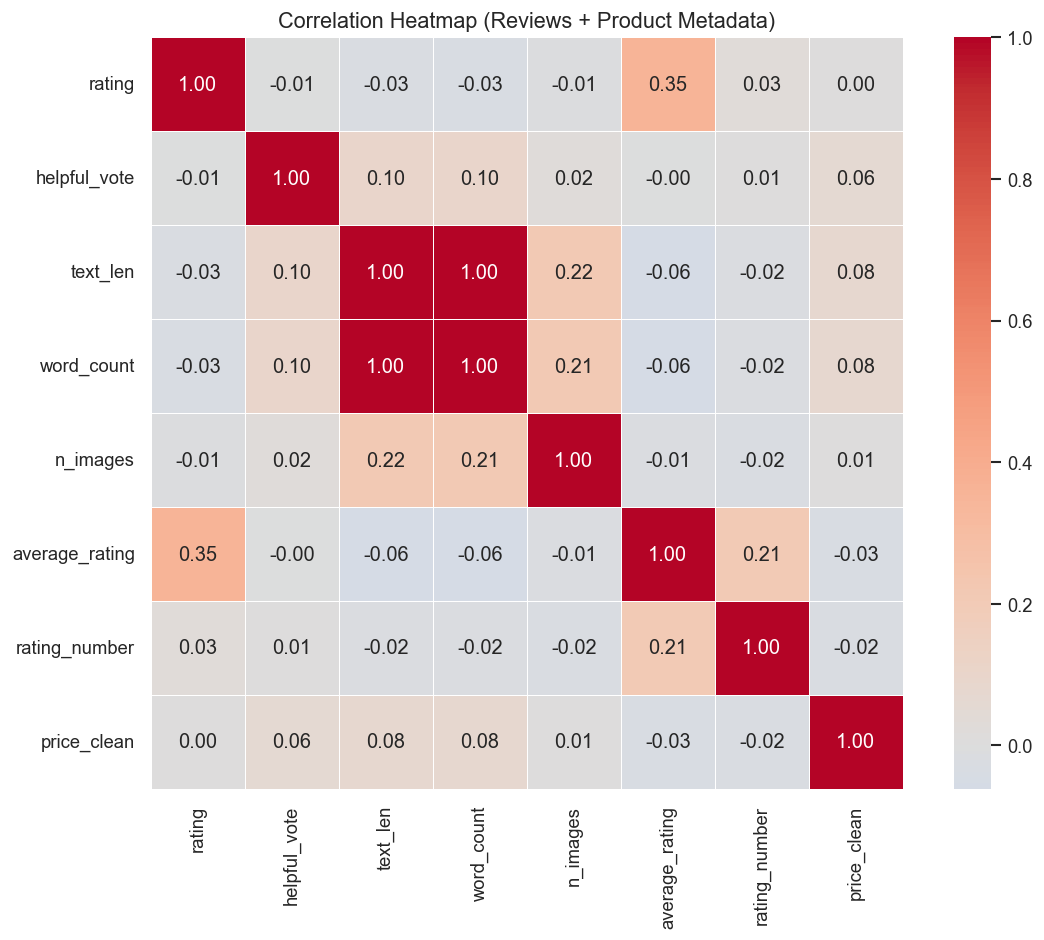

In [15]:
# ── Merge reviews with metadata for joint analysis ─────────────
merged = reviews.merge(
    meta[["parent_asin", "average_rating", "rating_number", "price_clean"]],
    on="parent_asin",
    how="left",
)

num_cols = ["rating", "helpful_vote", "text_len", "word_count",
            "n_images", "average_rating", "rating_number", "price_clean"]
corr = merged[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap (Reviews + Product Metadata)")
plt.tight_layout()
plt.show()

## 13 — Sentiment Label Distribution (for NLP modelling)

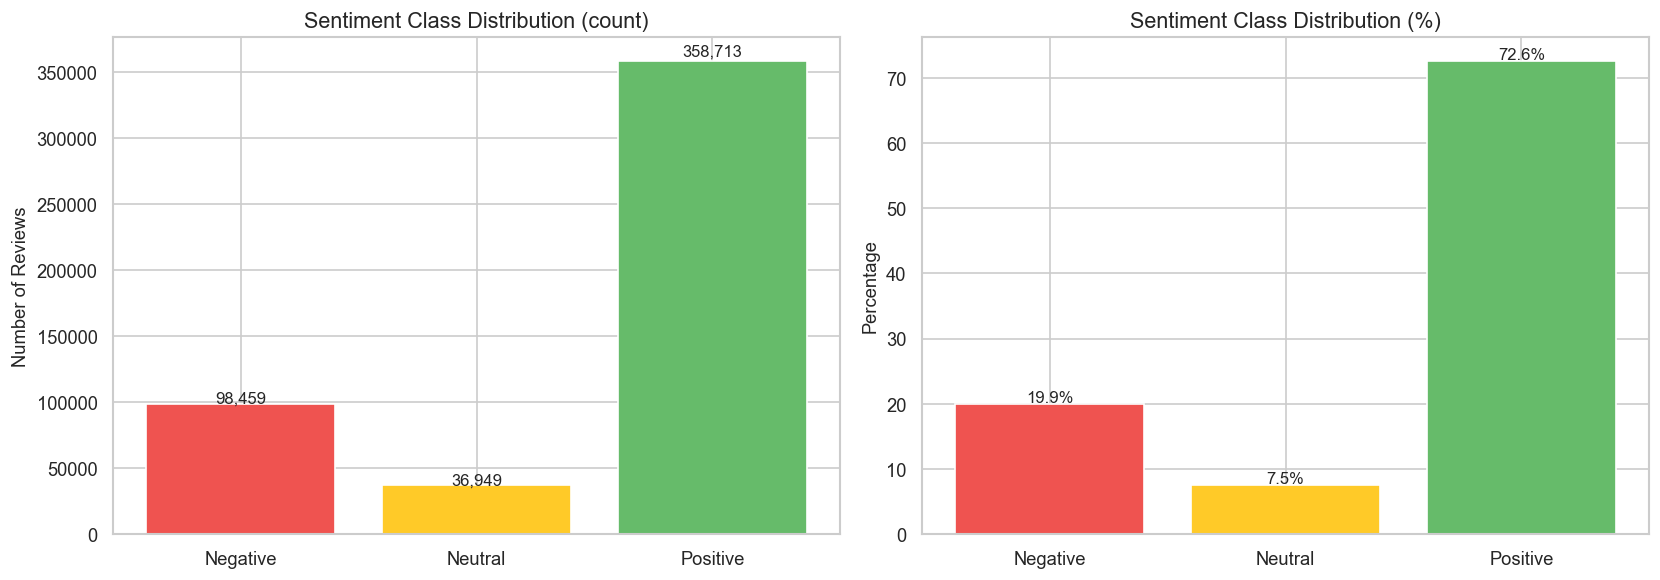

Class imbalance ratio (Positive / Negative): 3.6x


In [16]:
# ── Label mapping for potential sentiment / NLP tasks ──────────
def rating_to_sentiment(r):
    if r <= 2:
        return "Negative"
    elif r == 3:
        return "Neutral"
    else:
        return "Positive"

reviews["sentiment"] = reviews["rating"].apply(rating_to_sentiment)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts
sent_counts = reviews["sentiment"].value_counts().reindex(["Negative", "Neutral", "Positive"])
colors = ["#ef5350", "#ffca28", "#66bb6a"]
axes[0].bar(sent_counts.index, sent_counts.values, color=colors, edgecolor="white")
axes[0].set_title("Sentiment Class Distribution (count)")
axes[0].set_ylabel("Number of Reviews")
for i, v in enumerate(sent_counts.values):
    axes[0].text(i, v + v * 0.01, f"{v:,}", ha="center", fontsize=10)

# Percentage
sent_pct = sent_counts / sent_counts.sum() * 100
axes[1].bar(sent_pct.index, sent_pct.values, color=colors, edgecolor="white")
axes[1].set_title("Sentiment Class Distribution (%)")
axes[1].set_ylabel("Percentage")
for i, v in enumerate(sent_pct.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print("Class imbalance ratio (Positive / Negative):",
      f"{sent_counts['Positive'] / sent_counts['Negative']:.1f}x")

## 14 — Key Takeaways

In [17]:
# ── Programmatic summary ───────────────────────────────────────
summary = f"""
╔══════════════════════════════════════════════════════════════╗
║                    EDA SUMMARY                              ║
╠══════════════════════════════════════════════════════════════╣
║  Reviews dataset          : {reviews.shape[0]:>10,} rows                  ║
║  Metadata dataset         : {meta.shape[0]:>10,} rows                  ║
║  Unique products (reviews): {reviews['parent_asin'].nunique():>10,}                       ║
║  Unique users             : {reviews['user_id'].nunique():>10,}                       ║
║  Date range               : {str(reviews['date'].min().date())} → {str(reviews['date'].max().date())}  ║
║  Mean review rating       : {reviews['rating'].mean():>10.2f}                       ║
║  Verified purchase %      : {reviews['verified_purchase'].mean()*100:>9.1f}%                      ║
║  Reviews with images %    : {reviews['has_images'].mean()*100:>9.1f}%                      ║
║  Sentiment class balance  : Pos {sent_pct['Positive']:.1f}% / Neu {sent_pct['Neutral']:.1f}% / Neg {sent_pct['Negative']:.1f}%   ║
╚══════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════╗
║                    EDA SUMMARY                              ║
╠══════════════════════════════════════════════════════════════╣
║  Reviews dataset          :    494,121 rows                  ║
║  Metadata dataset         :     60,293 rows                  ║
║  Unique products (reviews):     60,274                       ║
║  Unique users             :    461,656                       ║
║  Date range               : 2001-02-05 → 2023-09-11  ║
║  Mean review rating       :       4.00                       ║
║  Verified purchase %      :      90.1%                      ║
║  Reviews with images %    :       4.3%                      ║
║  Sentiment class balance  : Pos 72.6% / Neu 7.5% / Neg 19.9%   ║
╚══════════════════════════════════════════════════════════════╝

